In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('unemployment analysis.csv')
conn = sqlite3.connect('unemployment_analysis.db')
df.to_sql('unemployment', conn)

In [ ]:
pd_unempl = pd.read_sql('SELECT * FROM unemployment', conn)

,index,Country Name,Country Code,1991,1992,1993,1994,1995,1996,1997,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,0,Africa Eastern and Southern,AFE,7.80,7.84,7.85,7.84,7.83,7.84,7.86,...,6.56,6.45,6.41,6.49,6.61,6.71,6.73,6.91,7.56,8.11
1,1,Afghanistan,AFG,10.65,10.82,10.72,10.73,11.18,10.96,10.78,...,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
2,2,Africa Western and Central,AFW,4.42,4.53,4.55,4.54,4.53,4.57,4.60,...,4.64,4.41,4.69,4.63,5.57,6.02,6.04,6.06,6.77,6.84
3,3,Angola,AGO,4.21,4.21,4.23,4.16,4.11,4.10,4.09,...,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
4,4,Albania,ALB,10.31,30.01,25.26,20.84,14.61,13.93,16.88,...,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,230,Samoa,WSM,2.10,2.38,2.63,3.04,3.19,3.47,3.90,...,8.75,8.67,8.72,8.50,8.31,8.58,8.69,8.41,9.15,9.84
231,231,"Yemen, Rep.",YEM,8.32,8.31,8.35,8.34,8.96,9.59,10.20,...,13.17,13.27,13.47,13.77,13.43,13.30,13.15,13.06,13.39,13.57
232,232,South Africa,ZAF,29.95,29.98,29.92,29.89,29.89,29.87,29.91,...,24.73,24.56,24.89,25.15,26.54,27.04,26.91,28.47,29.22,33.56
233,233,Zambia,ZMB,18.90,19.37,19.70,18.43,16.81,15.30,13.64,...,7.85,8.61,9.36,10.13,10.87,11.63,12.01,12.52,12.85,13.03


In [ ]:
germ_query = """SELECT * FROM unemployment WHERE "Country Name" = 'Germany'"""
germany = pd.read_sql(germ_query, conn)

,index,Country Name,Country Code,1991,1992,1993,1994,1995,1996,1997,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,48,Germany,DEU,5.32,6.32,7.68,8.73,8.16,8.82,9.86,...,5.38,5.23,4.98,4.62,4.12,3.75,3.38,3.14,3.81,3.54


In [ ]:
top_10_query = """SELECT "index", "Country Name", "Country Code", "2021" FROM unemployment ORDER BY "2021" DESC LIMIT 10"""
top_10_unemployment = pd.read_sql(top_10_query, conn)

,index,Country Name,Country Code,2021
0,232,South Africa,ZAF,33.56
1,49,Djibouti,DJI,28.39
2,199,Eswatini,SWZ,25.76
3,172,West Bank and Gaza,PSE,24.90
4,28,Botswana,BWA,24.72
5,123,Lesotho,LSO,24.60
6,39,"Congo, Rep.",COG,23.01
7,70,Gabon,GAB,22.26
8,149,Namibia,NAM,21.68
9,224,St. Vincent and the Grenadines,VCT,21.62


In [3]:
gfsp_query = """SELECT AVG("2021") as Average, MIN("2021") as Minimum, MAX("2021") as Maximum FROM unemployment 
WHERE "Country Name" IN ('Germany', 'France', 'Spain', 'Poland') """
gfsp_info = pd.read_sql(gfsp_query, conn)
gfsp_info

,Average,Minimum,Maximum
0,7.425,3.37,14.73


In [ ]:
df_long = df.melt(id_vars=['Country Name', 'Country Code'], value_vars=df.columns[2:].to_list(), 
                                      var_name='Year', value_name='Unemployment')

,Country Name,Country Code,Year,Unemployment
0,Africa Eastern and Southern,AFE,1991,7.80
1,Afghanistan,AFG,1991,10.65
2,Africa Western and Central,AFW,1991,4.42
3,Angola,AGO,1991,4.21
4,Albania,ALB,1991,10.31
...,...,...,...,...
7280,Samoa,WSM,2021,9.84
7281,"Yemen, Rep.",YEM,2021,13.57
7282,South Africa,ZAF,2021,33.56
7283,Zambia,ZMB,2021,13.03


In [ ]:
df_long.to_sql('unemployment_long', conn)

In [ ]:
long_stat_query = """ SELECT "Country Name", ROUND(AVG("Unemployment"), 2) as Average, MIN("Unemployment") as Minimum, 
MAX("Unemployment") as Maximum FROM unemployment_long WHERE "Country Name" IN ('Germany', 'France', 'Spain', 'Poland') 
GROUP BY "Country Name" """
long_stat = pd.read_sql(long_stat_query, conn)

,Country Name,Average,Minimum,Maximum
0,France,9.67,7.06,12.59
1,Germany,7.04,3.14,11.17
2,Poland,11.15,3.16,19.89
3,Spain,17.01,8.23,26.09


In [ ]:
year_avg_query = """ SELECT "Year", ROUND(AVG("Unemployment"), 2) as 'Average, %' FROM unemployment_long GROUP BY "Year" ORDER BY "Year" """
year_avg = pd.read_sql(year_avg_query, conn)

,Year,"Average, %"
0,1991,7.28
1,1992,7.63
2,1993,8.07
3,1994,8.25
4,1995,8.33
5,1996,8.49
6,1997,8.39
7,1998,8.44
8,1999,8.57
9,2000,8.44


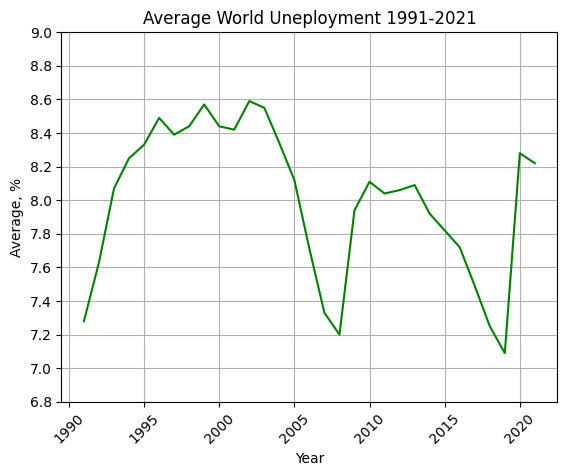

In [ ]:
year_avg['Year'] = pd.to_numeric(year_avg['Year'])
plt.plot(year_avg['Year'], year_avg['Average, %'], color='green')
plt.title('Average World Uneployment 1991-2021')
plt.xlabel('Year')
plt.ylabel('Average, %')
plt.tick_params('x', labelrotation=45)
plt.yticks(np.arange(6.8, 9.2, step=0.2))
plt.grid()
plt.show()

As in the previous analysis, this chart confirms that major global economic events — the early 1990s recession, the 2001 slowdown, the 2008 financial crisis, and the COVID-19 pandemic — had a measurable impact on worldwide unemployment levels.